In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import healpy as hp

def linear_parametric(t, vec, offset=[0,0,0]):
    return vec[0]*t+offset[0], vec[1]*t+offset[1], vec[2]*t+offset[2]

def amplitude_dot(vector_1, vector_2, opening_angle):
    if abs(np.dot(vector_1, vector_2)) > np.cos(opening_angle):
        return 1.0
    else:
        return 0.0

In [24]:
d=2
NSIDE = 2**d
NPIX = hp.nside2npix(NSIDE)
print("Number of pixels = {}".format(NPIX))

Number of pixels = 192


In [25]:
pixel_number = 10
# x, y, z
print("Pixel # {}".format(pixel_number))
print("Angles = {}".format(hp.pix2ang(NSIDE, pixel_number, nest=True)))
# Declination, Azimuth
print("Vector = {}".format(hp.pix2vec(NSIDE, pixel_number, nest=True)))

Pixel # 10
Angles = (0.8410686705679303, 0.19634954084936207)
Vector = (0.7310341861042718, 0.1454117405934622, 0.6666666666666666)


Effective f_esc: 0.4166666666666667


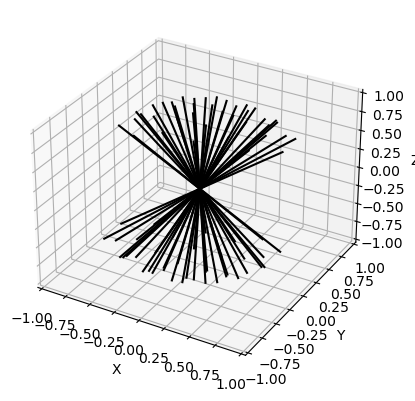

In [26]:
ax = plt.figure().add_subplot(projection='3d')

fraction = 0.0
for i in range(0,int(NPIX)):
    nested = False
    # x, y, z
    vector = hp.pix2vec(NSIDE, i, nest=nested)
    # Declination, Azimuth
    angles = hp.pix2ang(NSIDE, i, nest=nested)

    # setting up a parametric curve
    #reference_vector = np.array([0.0, 1.0, 0.0])
    reference_vector = hp.pix2vec(16, 91)
    opening_angle = 0.6*np.pi/2

    length = amplitude_dot(vector, reference_vector, opening_angle)
    t = np.linspace(0, length, 2)

    x, y, z = linear_parametric(t, vector)
    ax.plot(x, y, z, color='k')#, zuplims=zuplims, zlolims=zlolims, errorevery=estep)

    fraction = fraction + length
print("Effective f_esc: {}".format(fraction/NPIX))

ax.set_xlabel("X")
ax.set_xlim([-1.0,1.0])
ax.set_ylabel("Y")
ax.set_ylim([-1.0,1.0])
ax.set_zlabel("Z")
ax.set_zlim([-1.0,1.0])

plt.show()

In [28]:
# healpix level
d=2
NSIDE = 2**d
NPIX = hp.nside2npix(NSIDE)

# Jet information
opening_angle = 0.6*np.pi/2
reference_vector = hp.pix2vec(NSIDE, 9)

points = []
fraction = 0

for i in range(0,int(NPIX)):
    nested = False
    # x, y, z
    vector = hp.pix2vec(NSIDE, i, nest=nested)
    # Declination, Azimuth
    angles = hp.pix2ang(NSIDE, i, nest=nested)

    # setting up a parametric curve
    #reference_vector = np.array([0.0, 1.0, 0.0])
    
    length = amplitude_dot(vector, reference_vector, opening_angle)
    t = np.linspace(0, length, 2)

    length_scale = 10
    x, y, z = linear_parametric(t, vector)

    points.append([r'{}'.format(i), length_scale*x[0], length_scale*y[0], length_scale*z[0]])
    points.append([r'{}'.format(i), length_scale*x[1], length_scale*y[1], length_scale*z[1]])
    
    fraction = fraction + length

points_df = pd.DataFrame(data=points,
                         columns=['point', 'x', 'y', 'z'])
print("Escape fraction = {}".format(fraction/NPIX))

Escape fraction = 0.4166666666666667


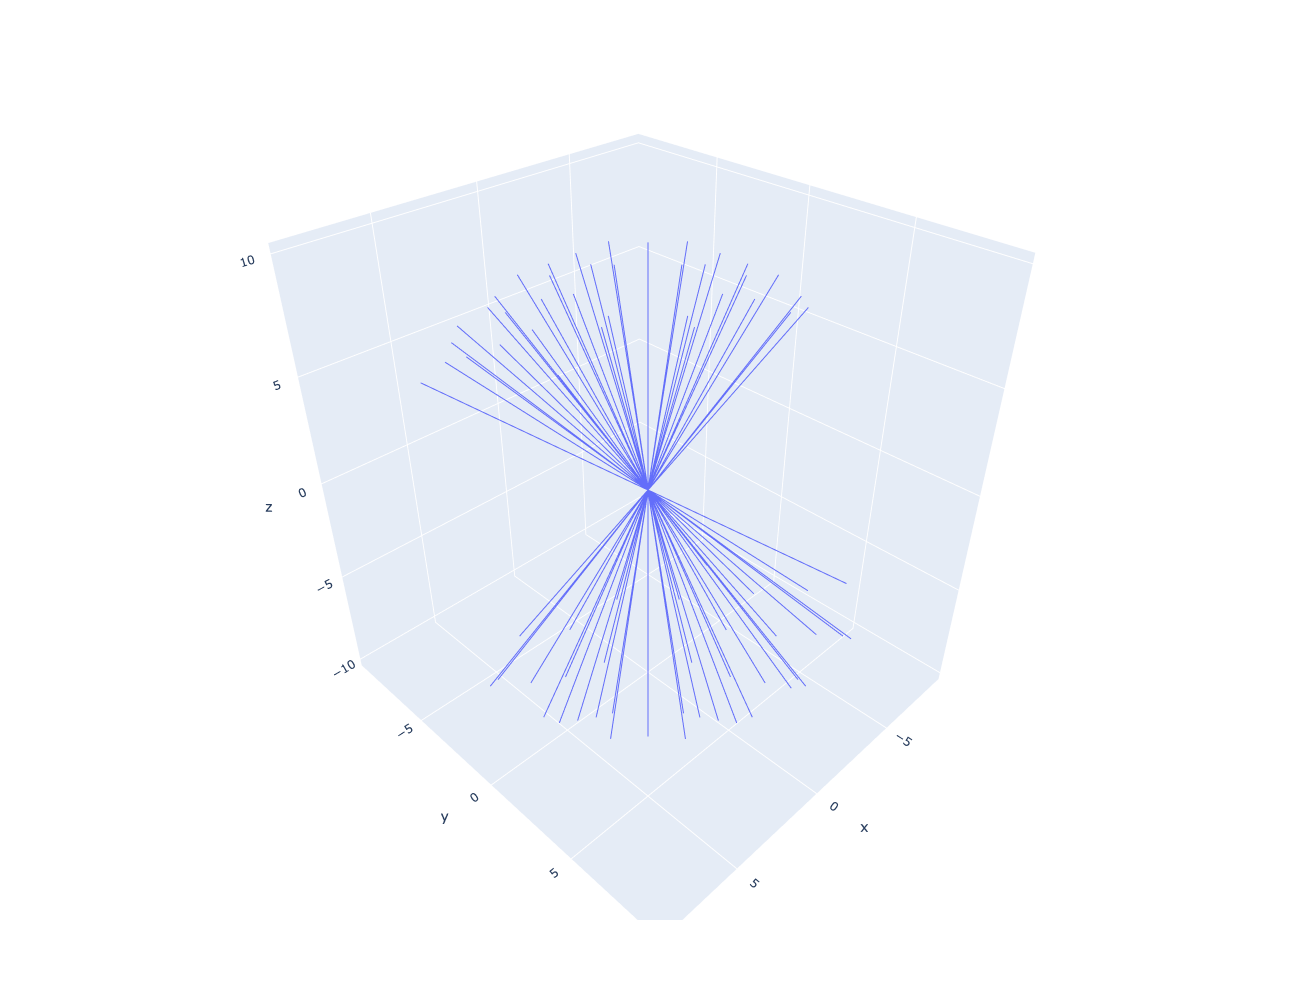

In [29]:
fig = px.line_3d(points_df, x="x", y="y", z="z", line_group = 'point', width=1000, height=1000)
fig.show()

In [79]:
points_df

,point,x,y,z
0,0,0.000000,0.000000,0.000000
1,0,0.072075,0.072075,0.994792
2,1,0.000000,0.000000,0.000000
3,1,-0.072075,0.072075,0.994792
4,2,0.000000,0.000000,0.000000
...,...,...,...,...
1531,765,-0.072075,0.072075,-0.994792
1532,766,0.000000,0.000000,0.000000
1533,766,-0.072075,-0.072075,-0.994792
1534,767,0.000000,0.000000,0.000000
